In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("European_Bank.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.drop(["Year", "CustomerId", "Surname"], axis=1, inplace=True)

In [8]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


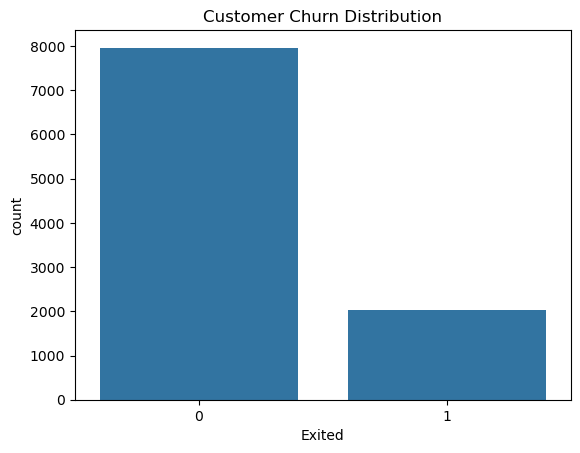

In [9]:
sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")

plt.show()

In [10]:
df['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

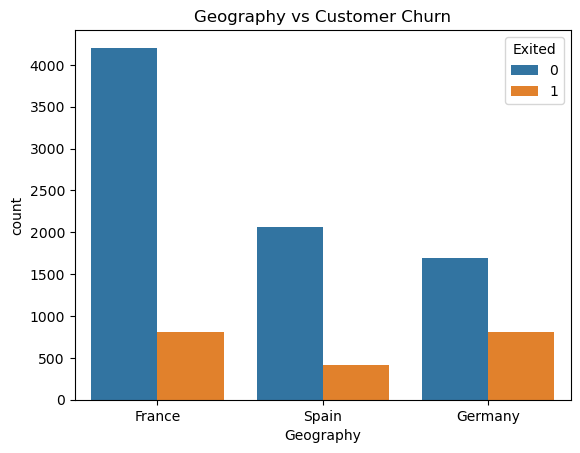

In [11]:
sns.countplot(x='Geography', hue='Exited', data=df)

plt.title("Geography vs Customer Churn")

plt.show()

In [12]:
pd.crosstab(df['Geography'], df['Exited'], normalize='index') * 100

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


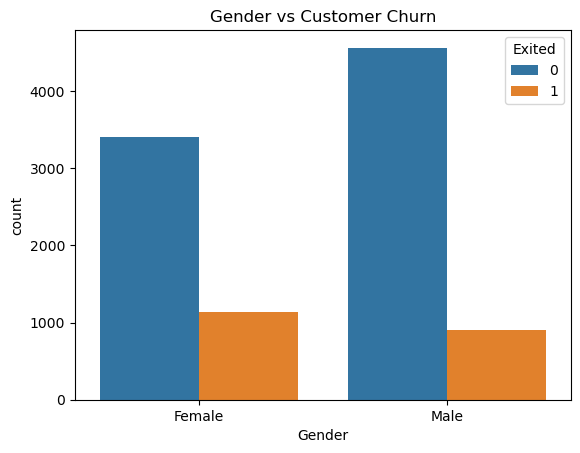

In [13]:
sns.countplot(x='Gender', hue='Exited', data=df)

plt.title("Gender vs Customer Churn")

plt.show()

In [14]:
pd.crosstab(df['Gender'], df['Exited'], normalize='index') * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


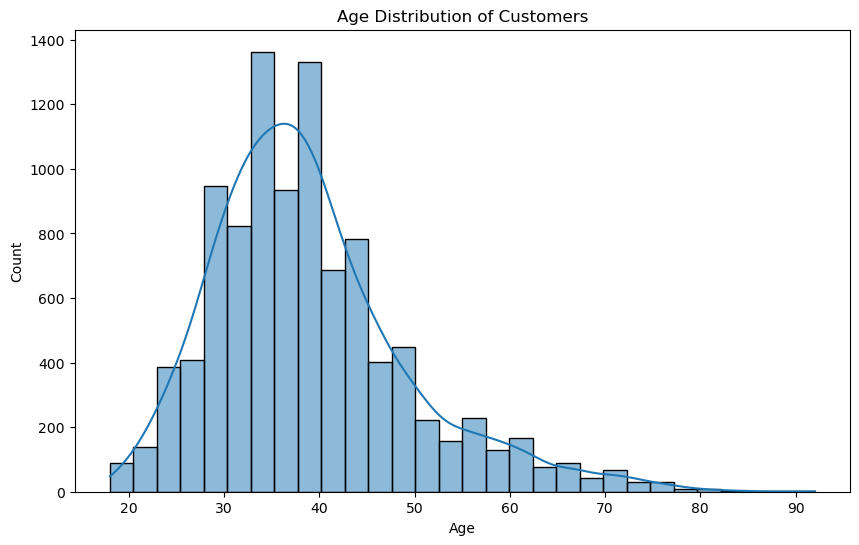

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution of Customers")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

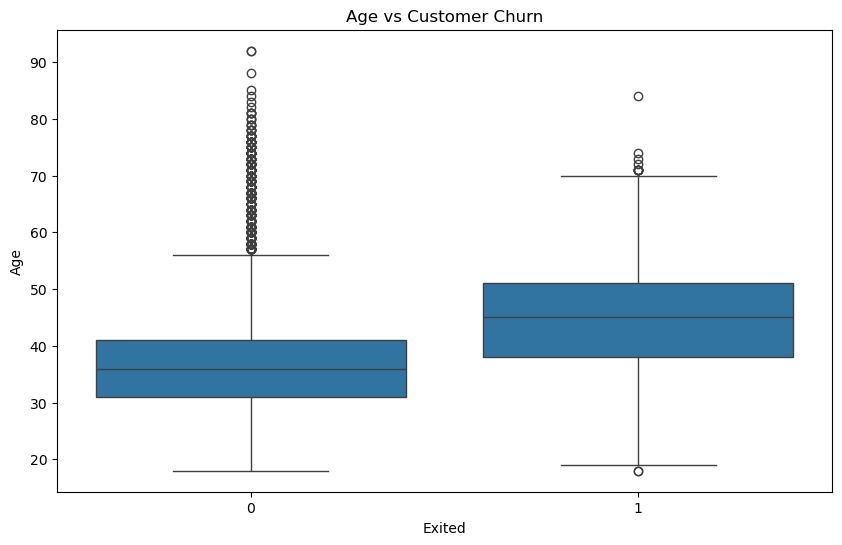

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Exited', y='Age', data=df)

plt.title("Age vs Customer Churn")

plt.show()

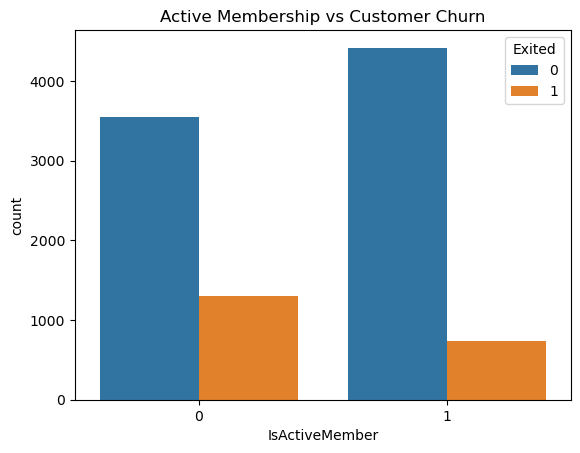

In [17]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)

plt.title("Active Membership vs Customer Churn")

plt.show()

In [18]:
pd.crosstab(df['IsActiveMember'], df['Exited'], normalize='index') * 100

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


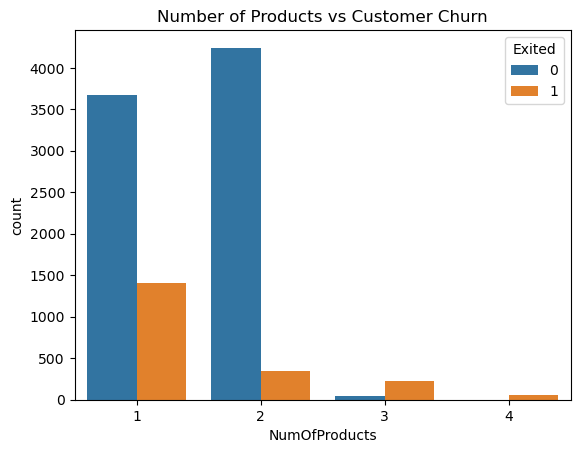

In [19]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)

plt.title("Number of Products vs Customer Churn")

plt.show()

In [20]:
pd.crosstab(df['NumOfProducts'], df['Exited'], normalize='index') * 100

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


In [21]:
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)

In [22]:
df[["Balance", "EstimatedSalary", "BalanceSalaryRatio"]].head()

,Balance,EstimatedSalary,BalanceSalaryRatio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744670
2,159660.80,113931.57,1.401362
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587035


In [23]:
df["ProductPerTenure"] = df["NumOfProducts"] / (df["Tenure"] + 1)

In [24]:
df[["NumOfProducts", "Tenure", "ProductPerTenure"]].head()

,NumOfProducts,Tenure,ProductPerTenure
0,1,2,0.333333
1,1,1,0.500000
2,3,8,0.333333
3,2,1,1.000000
4,1,2,0.333333


In [25]:
df["EngagementScore"] = (
    df["IsActiveMember"] *
    df["NumOfProducts"] *
    df["HasCrCard"]
)

In [26]:
df[["IsActiveMember", "NumOfProducts", "HasCrCard", "EngagementScore"]].head()

,IsActiveMember,NumOfProducts,HasCrCard,EngagementScore
0,1,1,1,1
1,1,1,0,0
2,0,3,1,0
3,0,2,0,0
4,1,1,1,1


In [27]:
df["AgeTenureRatio"] = df["Age"] / (df["Tenure"] + 1)

In [28]:
df[["Age", "Tenure", "AgeTenureRatio"]].head()

,Age,Tenure,AgeTenureRatio
0,42,2,14.000000
1,41,1,20.500000
2,42,8,4.666667
3,39,1,19.500000
4,43,2,14.333333


In [29]:
df = pd.get_dummies(
    df,
    columns=["Geography", "Gender"],
    drop_first=True
)

In [30]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductPerTenure,EngagementScore,AgeTenureRatio,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,14.000000,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,0,20.500000,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,4.666667,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,19.500000,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,14.333333,False,True,False


In [31]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [32]:
print(X.shape)

print(y.shape)

(10000, 15)
(10000,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [34]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(8000, 15)
(2000, 15)
(8000,)
(2000,)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [36]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [37]:
print(X_train_scaled.shape)

print(X_test_scaled.shape)

(8000, 15)
(2000, 15)


In [38]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

In [39]:
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred = lr_model.predict(X_test_scaled)

In [41]:
y_prob = lr_model.predict_proba(X_test_scaled)[:,1]

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.809


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.60      0.18      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [44]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7750061309383343


In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1543   50]
 [ 332   75]]


In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

In [48]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [50]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.84      0.42      0.56       407

    accuracy                           0.87      2000
   macro avg       0.86      0.70      0.74      2000
weighted avg       0.86      0.87      0.85      2000



In [51]:
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.8618464381176245


In [52]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

In [53]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

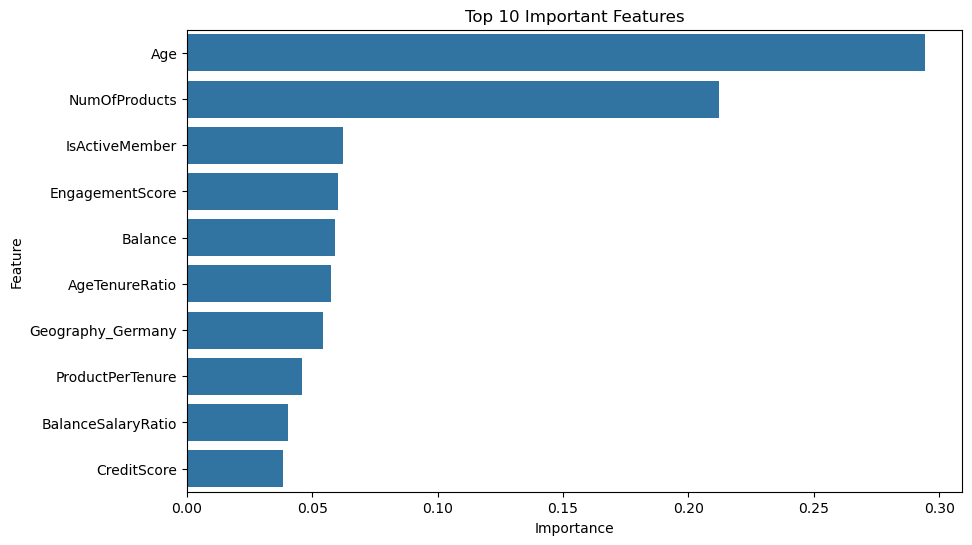

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [55]:
results_df = X_test.copy()

In [56]:
results_df["ActualExited"] = y_test.values

results_df["PredictedExited"] = rf_pred

results_df["ChurnProbability"] = rf_prob

In [57]:
risk_category = []

for prob in results_df["ChurnProbability"]:
    
    if prob < 0.3:
        risk_category.append("Low Risk")
        
    elif prob < 0.7:
        risk_category.append("Medium Risk")
        
    else:
        risk_category.append("High Risk")

In [58]:
results_df["RiskCategory"] = risk_category

In [59]:
results_df[[
    "ActualExited",
    "PredictedExited",
    "ChurnProbability",
    "RiskCategory"
]].head(10)

,ActualExited,PredictedExited,ChurnProbability,RiskCategory
5702,0,0,0.041422,Low Risk
3667,0,0,0.141413,Low Risk
1617,0,0,0.063474,Low Risk
5673,0,0,0.089819,Low Risk
4272,0,0,0.117428,Low Risk
8270,0,0,0.161674,Low Risk
7079,0,0,0.042719,Low Risk
5295,0,0,0.252260,Low Risk
845,0,1,0.525732,Medium Risk
5311,0,0,0.103280,Low Risk


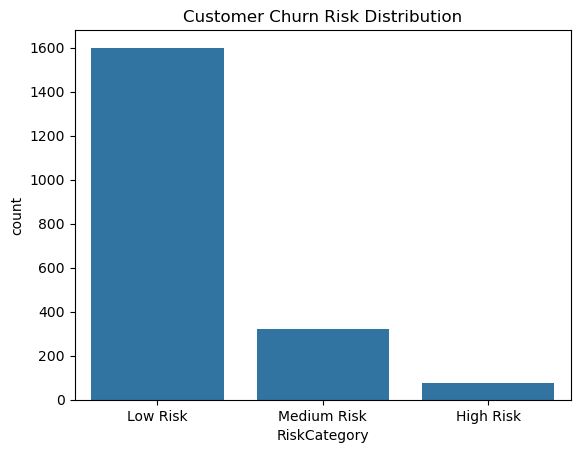

In [60]:
sns.countplot(x='RiskCategory', data=results_df)

plt.title("Customer Churn Risk Distribution")

plt.show()

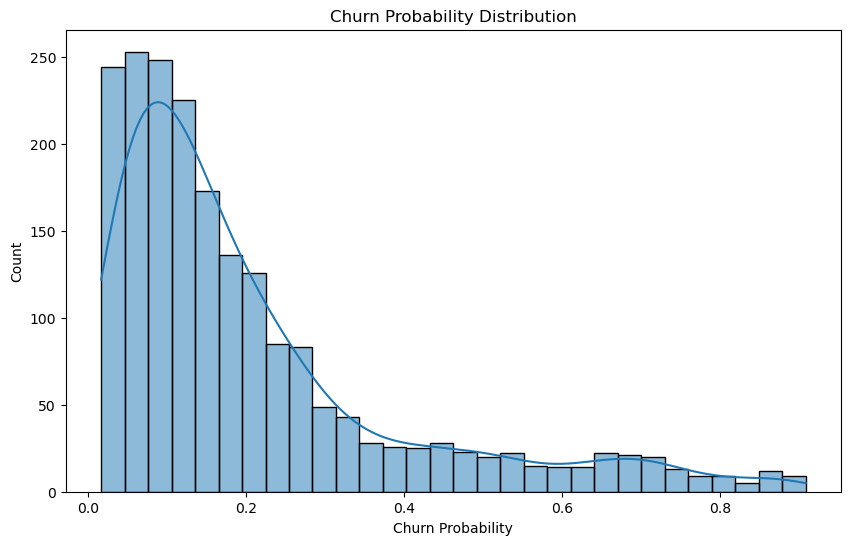

In [61]:
plt.figure(figsize=(10,6))

sns.histplot(results_df["ChurnProbability"], bins=30, kde=True)

plt.title("Churn Probability Distribution")

plt.xlabel("Churn Probability")

plt.ylabel("Count")

plt.show()

In [62]:
high_risk_customers = results_df[
    results_df["RiskCategory"] == "High Risk"
]

In [63]:
high_risk_customers.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductPerTenure,EngagementScore,AgeTenureRatio,Geography_Germany,Geography_Spain,Gender_Male,ActualExited,PredictedExited,ChurnProbability,RiskCategory
5386,642,48,9,118317.27,4,0,0,78702.98,1.503320,0.40,0,4.800,False,False,True,1,1,0.842686,High Risk
9800,762,35,3,119349.69,3,1,1,47114.18,2.533147,0.75,3,8.750,False,True,False,1,1,0.799729,High Risk
5010,575,49,7,121205.15,4,1,1,168080.53,0.721109,0.50,4,6.125,True,False,True,1,1,0.904348,High Risk
5922,555,44,3,105770.70,3,1,0,60533.96,1.747266,0.75,0,11.000,False,False,False,1,1,0.837191,High Risk
5363,771,51,5,135506.58,3,1,1,152479.64,0.888681,0.50,3,8.500,False,True,True,1,1,0.875836,High Risk


In [64]:
print("High Risk Customers:", len(high_risk_customers))

High Risk Customers: 78
